<a href="https://colab.research.google.com/github/KS6Git/Python_EDA_Raja/blob/main/Simple%26Multiple_LinearAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear Regression Assignment**

# ============================================================
# 🌼 SIMPLE LINEAR AND MULTIPLE LINEAR REGRESSION ASSIGNMENT

Problem Statement:

This assignment focuses on understanding and applying Simple Linear Regression and Multiple Linear Regression to predict outcomes based on given datasets. By exploring the datasets, students will learn how to build regression models, evaluate their performance, and interpret their coefficients to derive meaningful insights.

# ============================================================

#1. Setup and Data Preparation:
# Importing necessary Libraries

In [ ]:
# Data Handling
import pandas as pd                  # DataFrame creation and data manipulation
import numpy as np                   # Numerical computations

# Visualization
import matplotlib.pyplot as plt      # Basic plotting
import seaborn as sns                # Enhanced plotting (built on Matplotlib)

# Machine Learning Algorithms & Utilities
from sklearn.linear_model import LinearRegression        # Linear Regression Model
from sklearn.model_selection import train_test_split     # Split data into train and test sets

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, r2_score

# Plotting in Jupyter/Colab
%matplotlib inline

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# 2. Loading the dataset for regression analysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##1st Dataset - Medical Cost Personal Dataset

In [ ]:
# pd.read_csv('/content/drive/MyDrive/Colab Notebooks/insurance.csv')
data_URL = "/content/drive/MyDrive/Colab Notebooks/insurance.csv"

In [ ]:
df_Med = pd.read_csv(data_URL)

##2nd Dataset - Startup - Multiple Linear Reg Dataset

In [ ]:
# 2. Startup - Multiple Linear Regression download

df_St = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/50_Startups.csv')

##3rd Dataset - Calculate Concrete Strength

In [ ]:
df_Con = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/concrete_data.csv')

## **1. Medical Cost Personal Dataset**

###1.1 EDA - Analyse & Summarise the Medical Cost Personal Dataset

### **Show dataset & Summarise**


In [ ]:
df_Med.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df_Med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df_Med.describe()


,age,sex,bmi,children,smoker,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.494768,30.663397,1.094918,0.204783,13270.422265
std,14.049960,0.500160,6.098187,1.205493,0.403694,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,4740.287150
50%,39.000000,0.000000,30.400000,1.000000,0.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,16639.912515
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010


In [ ]:
df_Med.shape

(1338, 7)

In [ ]:
df_Med.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
Num_columns = ['age', 'bmi', 'children', 'charges']
Cat_columns = ['sex', 'smoker', 'region']
for col in Cat_columns:
  #print(f"{col}: {data_Med[col].unique()}") ... same thing
  print(col," --> ", df_Med[col].unique())

sex  -->  ['female' 'male']
smoker  -->  ['yes' 'no']
region  -->  ['southwest' 'southeast' 'northwest' 'northeast']


### **1.2 Pre-processing**

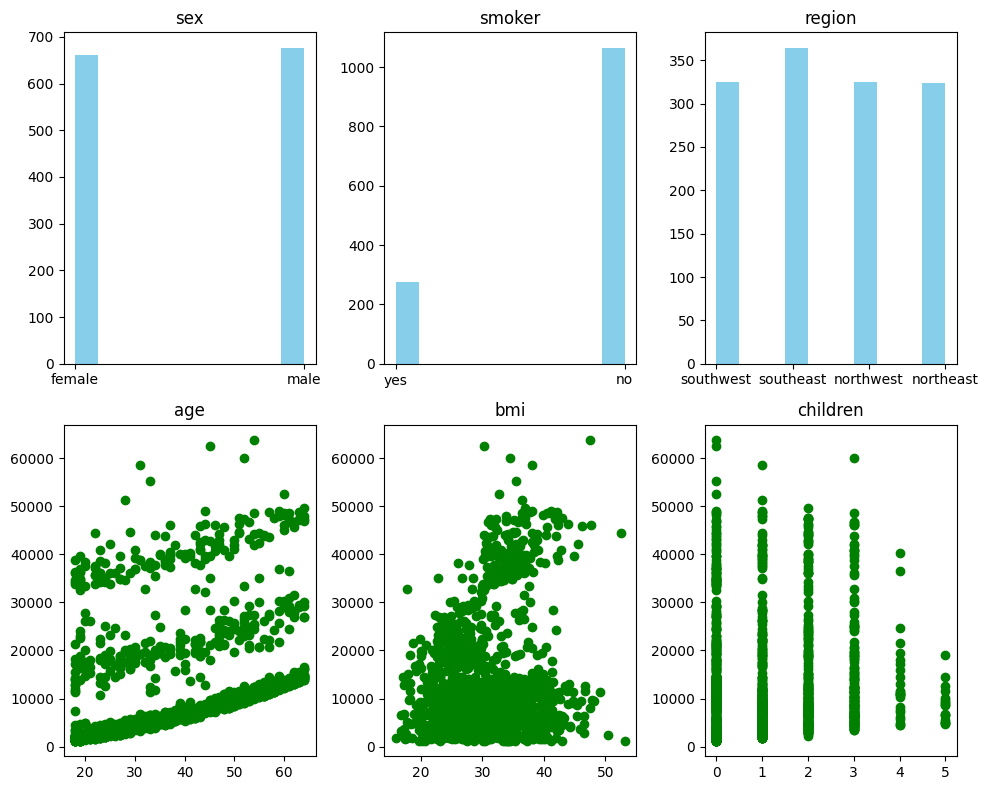

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(10,8))

# histogram
for i, col in enumerate(Cat_columns):
  axes[0, i].hist(df_Med[col], color='skyblue')
  axes[0, i].set_title(col)

# Filter Num_columns to exclude 'charges' for scatter plots against 'charges'
num_features_for_scatter = [col for col in Num_columns if col != 'charges']

# scatterplot
for i, col in enumerate(num_features_for_scatter):
  axes[1, i].scatter(df_Med[col], df_Med['charges'], color='green')
  axes[1, i].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(20,5))

features = ['age', 'bmi', 'children', 'charges'] # column names; control how many plots
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold' ]

<Figure size 2000x500 with 0 Axes>

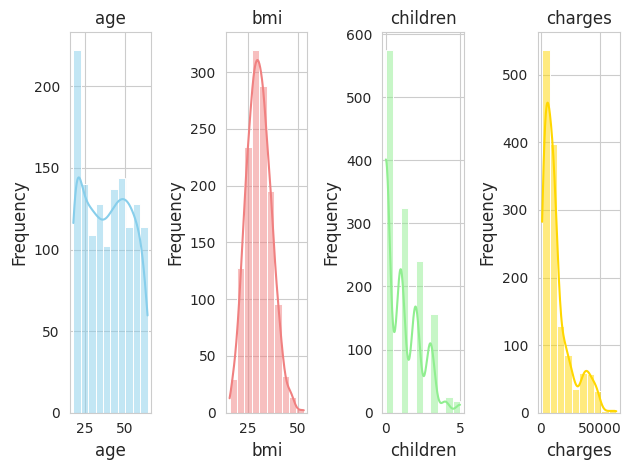

In [ ]:
for i, col in enumerate(features):      # enumerate() gives you the position, and plt.subplot()
                                        # uses that position to place each plot correctly.

    plt.subplot(1, 4, i + 1)            # 1 row 4 columns:Creates 4 plots side by side for each feature


    sns.histplot(df_Med[col], kde=True, bins=10, color=colors[i])

    plt.title(f'{col}', fontsize=12)
    plt.xlabel(f'{col}', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

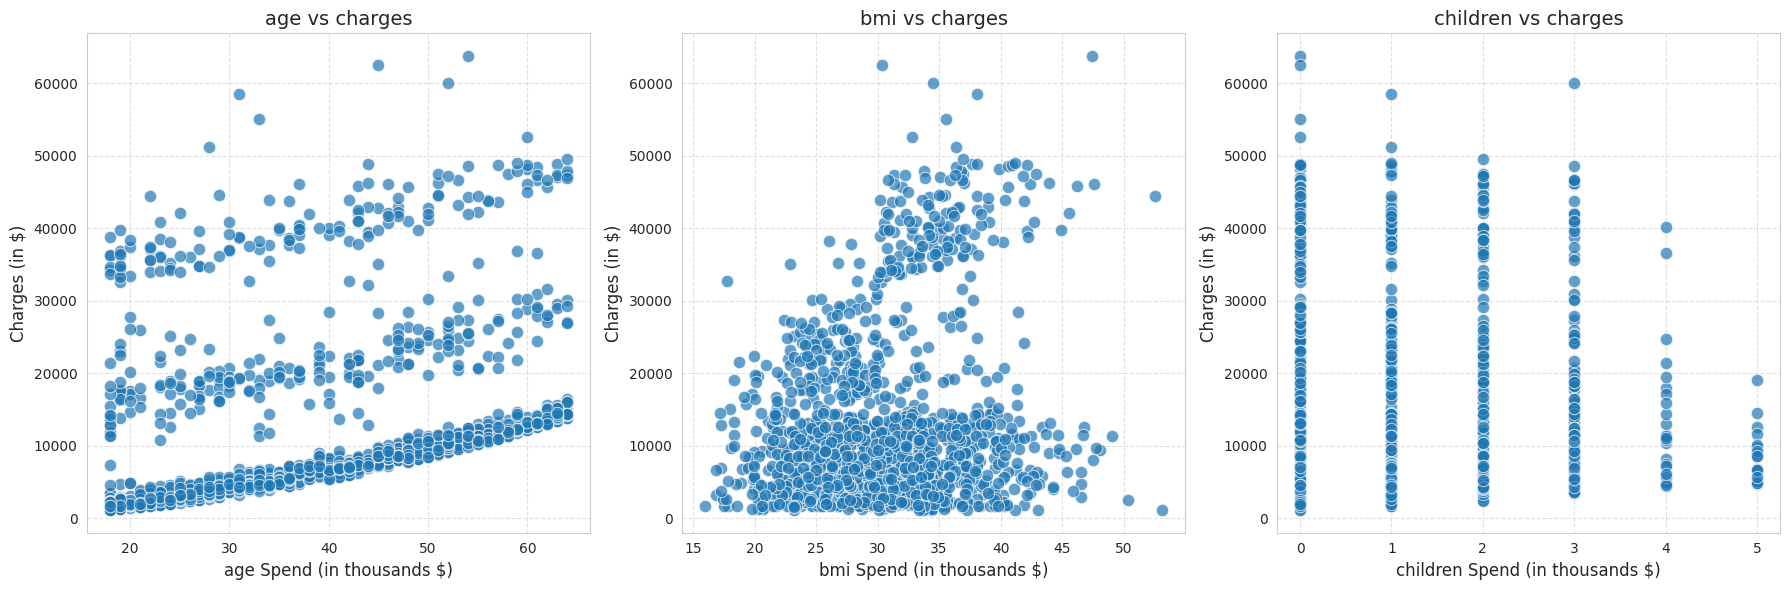

In [ ]:
# Scatter plots for age, bmi, children vs charges
plt.figure(figsize=(18, 6))

for i, col in enumerate(['age', 'bmi', 'children']):    # features or INPUT
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x=col, y='charges', data=df_Med, s=80, alpha=0.7) # TV-sales, Radio-sales, Newspaper-sales

    plt.title(f'{col} vs charges', fontsize=14)
    plt.xlabel(f'{col} Spend (in thousands $)', fontsize=12)
    plt.ylabel('Charges (in $)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

##There seems to be correlation between age and charges, but not others

## **2. Simple Linear Regression**

###Selecting one indep't var(predictor) and one dependent var (response

In [ ]:
# Feature (x) and Response (y)
x = df_Med['age']
y = df_Med['charges']

In [ ]:
x


,age
0,19
1,18
2,28
3,33
4,32
...,...
1333,50
1334,18
1335,18
1336,21


In [ ]:
df_Med[['age', 'charges']]

,age,charges
0,19,16884.92400
1,18,1725.55230
2,28,4449.46200
3,33,21984.47061
4,32,3866.85520
...,...,...
1333,50,10600.54830
1334,18,2205.98080
1335,18,1629.83350
1336,21,2007.94500


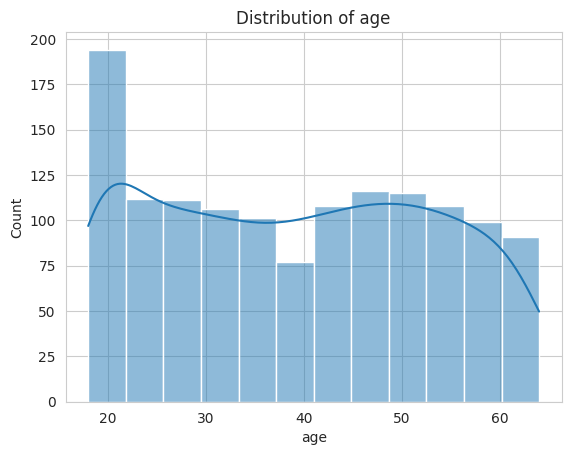

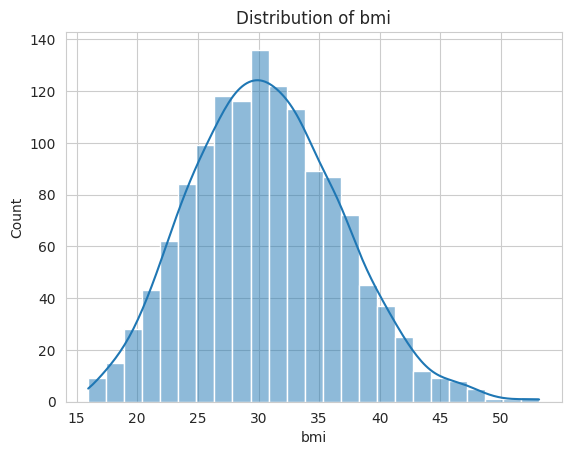

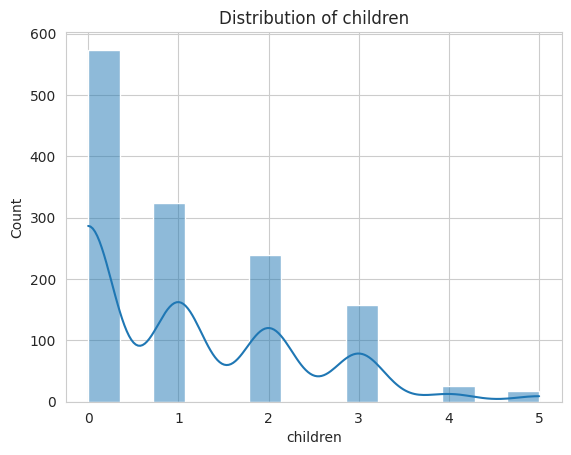

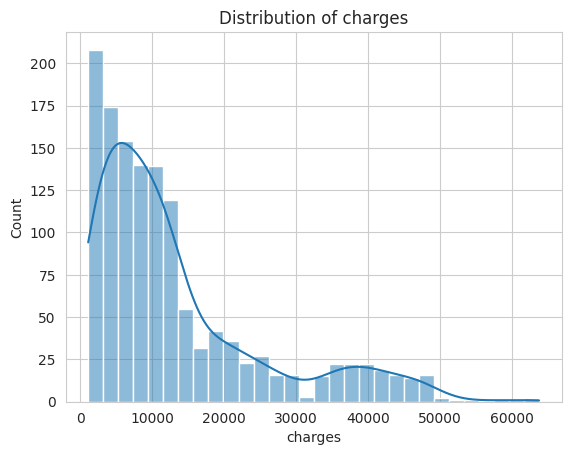

In [ ]:
for col in Num_columns:
  plt.figure()
  sns.histplot(df_Med[col], kde = 'True')

  plt.title(f'Distribution of {col}')

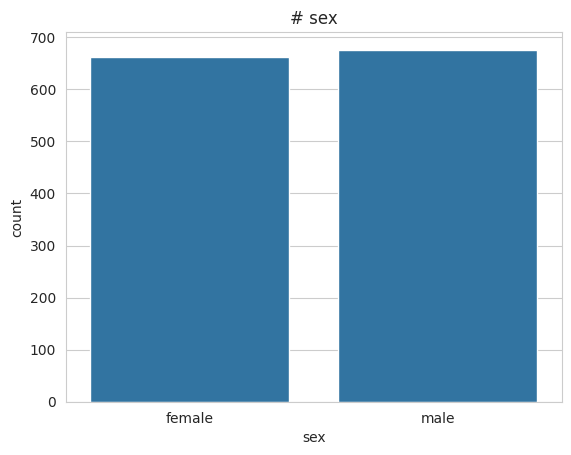

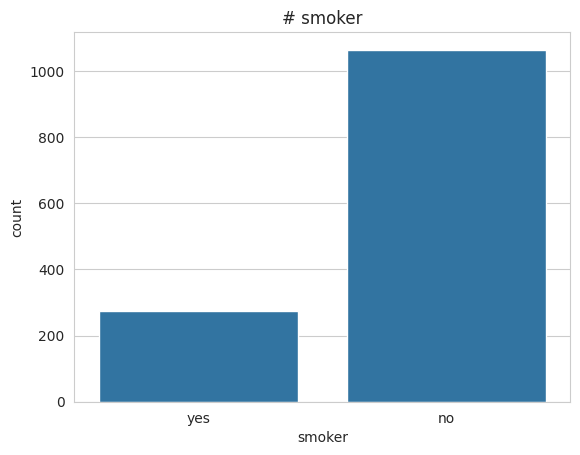

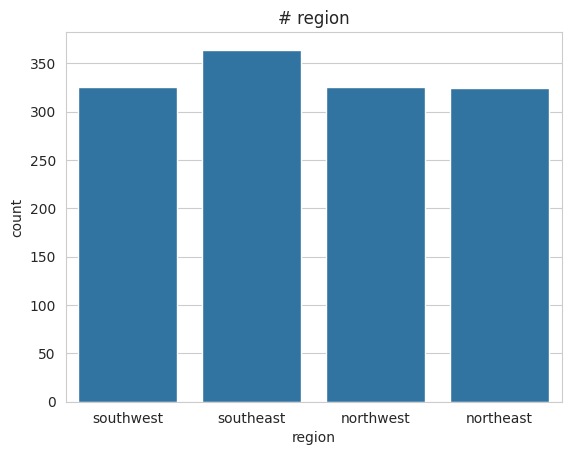

In [ ]:
for col in Cat_columns:
  plt.figure()
  sns.countplot(x = df_Med[col])

  plt.title(f'# {col}')

Text(0.5, 1.0, 'Boxplot of charges vs region')

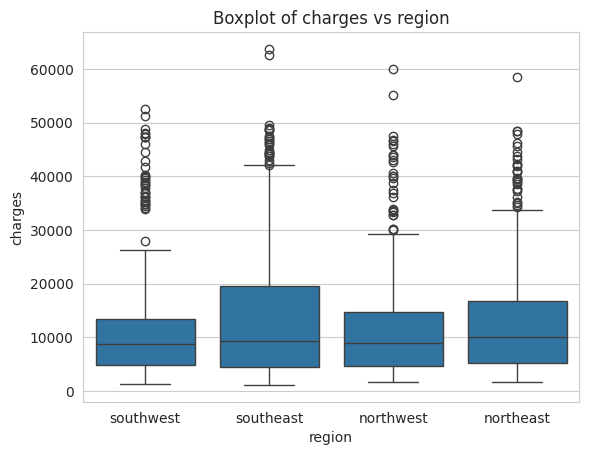

In [ ]:
plt.figure()
sns.boxplot(x=df_Med[col], y=df_Med['charges'])
plt.title(f'Boxplot of charges vs {col}')

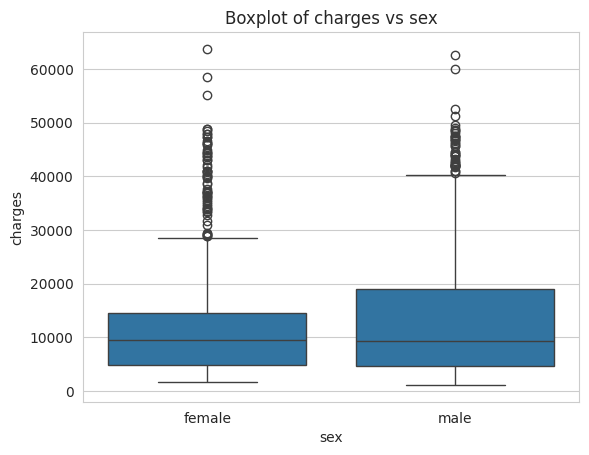

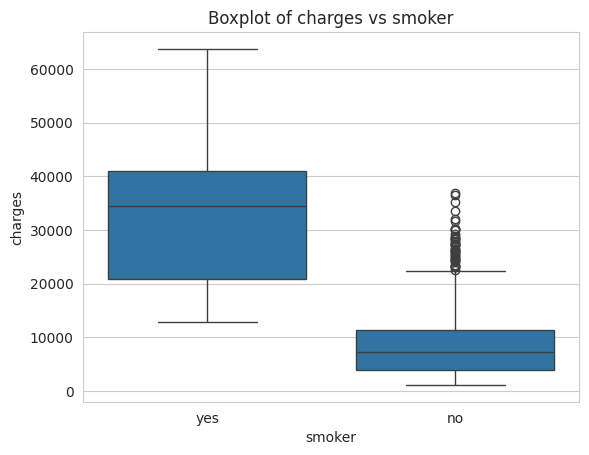

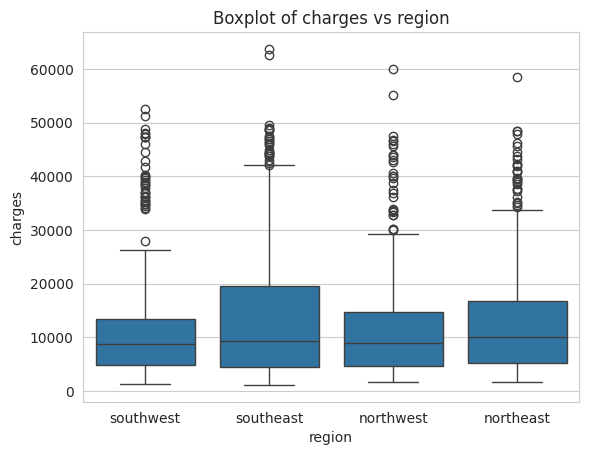

In [ ]:
for col in Cat_columns:
  plt.figure()
  sns.boxplot(x=df_Med[col], y=df_Med['charges'])
  plt.title(f'Boxplot of charges vs {col}')

Text(0.5, 1.0, 'BMI vs Charges by Smoker')

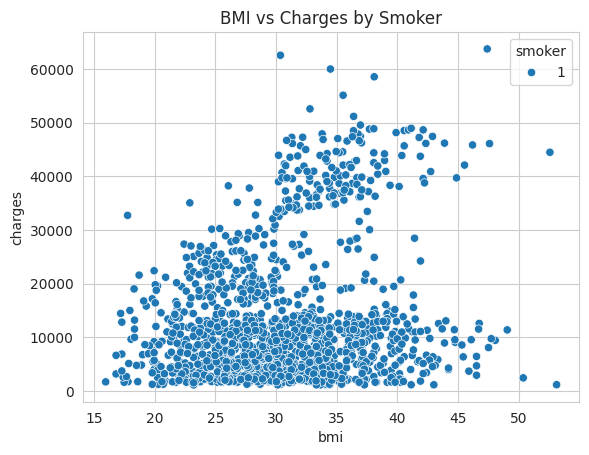

In [ ]:
plt.figure()
sns.scatterplot(x=df_Med['bmi'], y=df_Med['charges'], hue=df_Med['smoker'])
plt.title('BMI vs Charges by Smoker')

In [ ]:
# changing sex and smoker to 0 or 1 to make it a numerical feature
df_Med['sex']    = np.where(df_Med["sex"] == 'male', 0, 1)
df_Med['smoker'] = np.where(df_Med["smoker"] == 'no', 0, 1)

x = df_Med[['age']]  # features
y = df_Med['charges']                 # label/target




### **Training the Simple Linear Regression model**


In [ ]:
# Splitting data into Training & Testing
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 1070 samples
Testing set size: 268 samples


In [ ]:
# Initialize Linear Regression model & fitting
linear_model = LinearRegression() # y = mx + c


In [ ]:
linear_model

LinearRegression()

### **Training**

In [ ]:
# training or fitting the model
linear_model.fit(X_train,y_train)

LinearRegression()

### **Predicting the result**


In [ ]:
# prediction
y_pred = linear_model.predict(X_test)


In [ ]:
y_pred

array([14703.77387469, 12538.40483659, 19275.10851067, 14944.37043448,
        8448.26332018, 12057.21171701,  8448.26332018, 19275.10851067,
       10613.63235828, 15666.16011384, 11094.82547785, 13741.38763553,
       10854.22891807, 14944.37043448, 18312.72227152, 15184.96699426,
       15666.16011384, 15184.96699426, 14944.37043448, 14222.58075511,
        9891.84267891, 14222.58075511,  8448.26332018,  9170.05299954,
       15906.75667363, 16869.14291279, 18312.72227152, 10373.03579849,
       15184.96699426,  8207.66676039, 13500.79107574, 17590.93259215,
        8929.45643976, 11094.82547785, 10132.4392387 , 14703.77387469,
        8929.45643976, 14222.58075511, 16387.94979321, 12538.40483659,
        8448.26332018,  9170.05299954, 17350.33603236, 18072.12571173,
       11816.61515722, 18072.12571173,  8929.45643976,  9891.84267891,
       14222.58075511, 11335.42203764, 19034.51195088,  8207.66676039,
       13500.79107574,  8207.66676039, 17350.33603236, 15906.75667363,
      

### **Calculate Accuracy**

In [ ]:
# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# R2 Score
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Mean Absolute Error (MAE): {mae:.2f}")
print(f"Linear Regression R-squared (R²) Score: {r2:.2f}")

Linear Regression Mean Absolute Error (MAE): 9173.26
Linear Regression R-squared (R²) Score: 0.12


In [ ]:
mae

9173.258196746589

In [ ]:
r2

0.12408973539501944

### **Visualisation of Linear Regression**

In [ ]:
df_Med.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,1,southeast,1725.55230
2,28,1,33.000,3,1,southeast,4449.46200
3,33,1,22.705,0,1,northwest,21984.47061
4,32,1,28.880,0,1,northwest,3866.85520


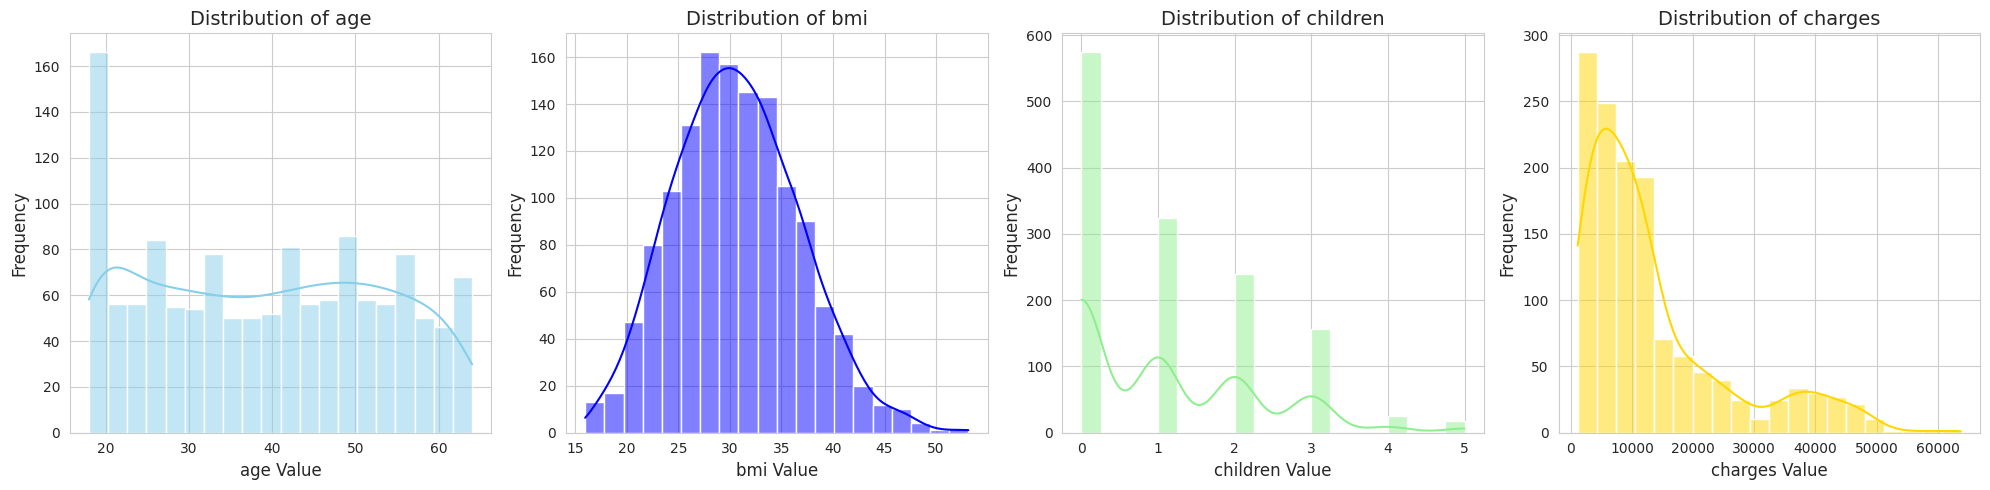

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(20,5))

features = ['age', 'bmi', 'children', 'charges'] # column names; control how many plots
colors = ['skyblue', 'blue', 'lightgreen', 'gold']  # defines a color for each plot

for i, col in enumerate(features):      # enumerate() gives you the position, and plt.subplot()
                                        #   uses that position to place each plot correctly.
                                        #   i = 0, col = 'TV'
                                        #   i = 1, col = 'Radio'

    plt.subplot(1, 4, i + 1)            # 1 row 4 columns:Creates 4 plots side by side for each feature
                                        #  Each loop iteration:
                                        #     selects the next subplot
                                        #     plots the corresponding column
                                        # Same as writing plt.subplot(1,4,1), plt.subplot(1,4,2) etc



    sns.histplot(df_Med[col], kde=True, bins=20, color=colors[i])
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(f'{col} Value', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

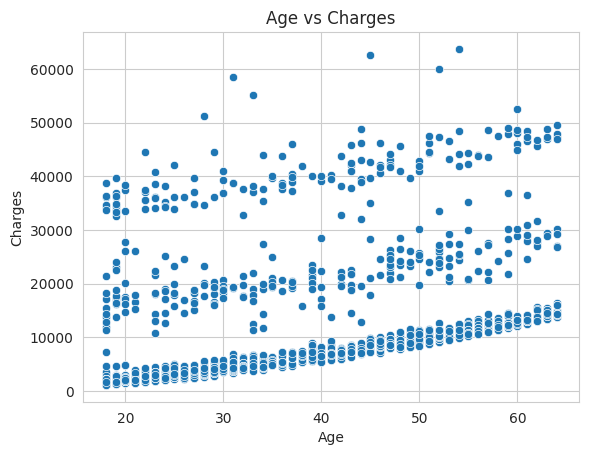

In [ ]:
sns.scatterplot(x=df_Med['age'], y=df_Med['charges'])

plt.title('Age vs Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()


### **Determine slope - m**

In [ ]:
linear_model.coef_

array([240.59655979])

### **Determine intercept - c**

In [ ]:
linear_model.intercept_ # intercept (c)

np.float64(3876.928684191691)

## **y = 240x + 3876**

<Axes: xlabel='age', ylabel='charges'>

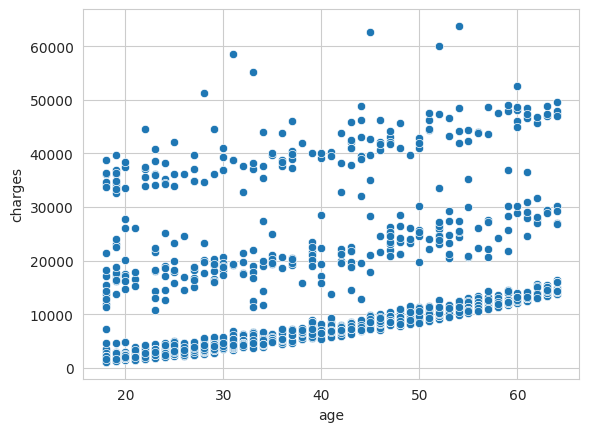

In [ ]:
sns.scatterplot(x=df_Med['age'], y=df_Med['charges'])

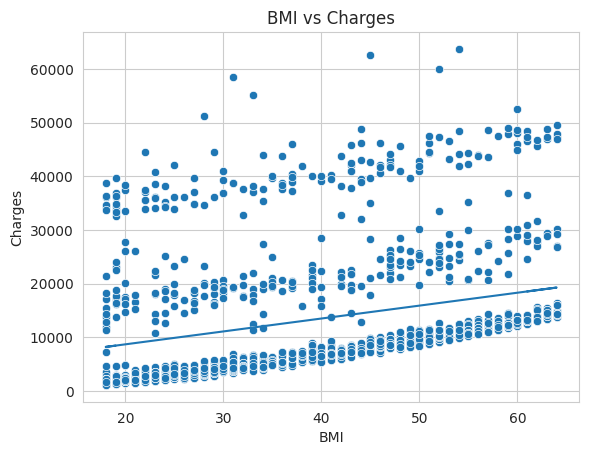

In [ ]:
sns.scatterplot(x=df_Med['age'], y=df_Med['charges'])
plt.plot(x, linear_model.predict(x))

plt.title('Age vs Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

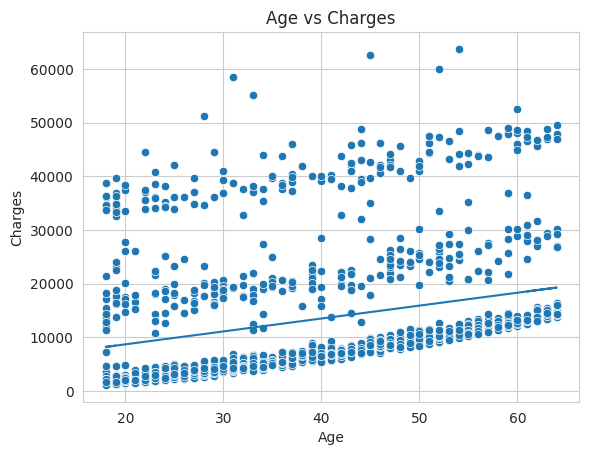

In [ ]:
sns.scatterplot(x=df_Med['age'], y=df_Med['charges'])
plt.plot(x, linear_model.predict(x))

plt.title('Age vs Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

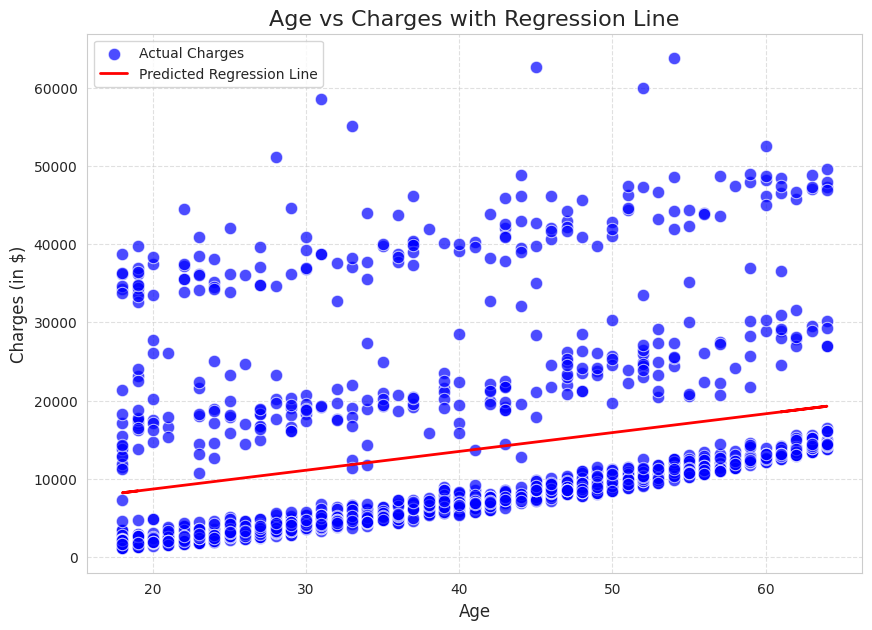

In [ ]:
# Visualizing Regression Line - proper plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x=df_Med['age'], y=df_Med['charges'], color='blue', s=80, alpha=0.7, label='Actual Charges')
plt.plot(x, linear_model.predict(x), color='red', linewidth=2, label='Predicted Regression Line')

plt.title('Age vs Charges with Regression Line', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Charges (in $)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
# Summary
# 1. Get Model:   > model = LinearRegression()      # y = mx + c
# 2. Split Model: > X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# 3. Train Model: > model.fit(X_train, y_train)
# 4. Test Model:  > y_pred = model.predict(X_test)
# 5. Get m:       > model.coef_
#    Get c:       > model.intercept_
#    Get Formula:     > Sales = (model.coef_)x + (model.intercept_)

## **Multiple Linear Regression**

In [ ]:
# Feature (x) and Target (y)
x = df_Med[['age', 'bmi']]  # features
y = df_Med['charges']                 # target


In [ ]:
# Splitting data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 1070 samples
Testing set size: 268 samples


### **y = m1x1 + m2x2 + c**

## Loading the Linear Regression Model

In [ ]:
# Initialize Linear Regression model
model = LinearRegression()

In [ ]:
model

LinearRegression()

In [ ]:
# Train the model
model.fit(X_train, y_train)

LinearRegression()

## Predicting the Outcome

In [ ]:
  y_pred = model.predict(X_test)

In [ ]:
y_pred

array([12827.51175996, 12416.04227446, 17645.30443342, 13239.86114997,
        9240.01076808, 16229.08222579,  6128.888602  , 21290.65969872,
        6414.65618179, 14885.44051354,  9214.19805927, 13723.57779033,
       10707.22492408, 18732.70363458, 21392.81895625, 17828.49095963,
       19513.25541024, 17064.35569077, 14002.34244639, 12945.57727268,
        7929.81815761, 14836.06777551,  8737.20314528, 12519.71490575,
       14920.68418645, 17324.29318071, 19467.59503211, 10527.57539699,
       13746.48696926,  8427.40004675, 13073.05636846, 17712.85348728,
       10663.44757262,  7742.16258462, 10171.46107005, 17667.03512941,
        7861.61825346, 13942.92265606, 14048.40723953, 14129.55772585,
        8141.77306564,  9722.84750392, 18803.96504833, 16054.93962973,
       13640.10510023, 16729.76038664, 10253.26240665,  8062.13595308,
       15950.84520238, 14065.80948743, 20535.93801292,  8172.68829047,
       17082.28557132,  7099.26017469, 18350.77659884, 16240.5541963 ,
      

In [ ]:
y_test

,charges
764,9095.06825
887,5272.17580
890,29330.98315
1293,9301.89355
259,33750.29180
...,...
109,47055.53210
575,12222.89830
535,6067.12675
543,63770.42801


## Calculating the accuracy of the model

In [ ]:
# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# R2 Score
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Mean Absolute Error (MAE): {mae:.2f}")
print(f"Linear Regression R-squared (R²) Score: {r2:.2f}")

Linear Regression Mean Absolute Error (MAE): 9222.66
Linear Regression R-squared (R²) Score: 0.15


## Visualising the Result

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

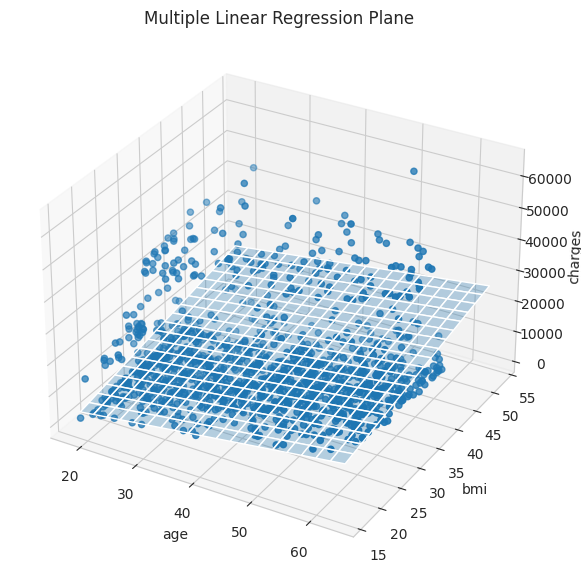

In [ ]:
# Create figure
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter actual data points
ax.scatter(df_Med['age'], df_Med['bmi'], y)

# Create grid for plane
age_range = np.linspace(df_Med['age'].min(), df_Med['age'].max(), 20)
bmi_range = np.linspace(df_Med['bmi'].min(), df_Med['bmi'].max(), 20)
age_grid, bmi_grid = np.meshgrid(age_range, bmi_range)

# Predict sales for each grid point
charges_pred = model.predict(
    np.c_[age_grid.ravel(), bmi_grid.ravel()]
)
charges_pred = charges_pred.reshape(age_grid.shape)

# Plot regression plane
ax.plot_surface(age_grid, bmi_grid, charges_pred, alpha=0.3)

# Labels
ax.set_xlabel("age")
ax.set_ylabel("bmi")
ax.set_zlabel("charges")

plt.title("Multiple Linear Regression Plane")
plt.show()

In [ ]:
age_range = np.linspace(df_Med['age'].min(), df_Med['age'].max(), 20)

In [ ]:
age_range

array([18.        , 20.42105263, 22.84210526, 25.26315789, 27.68421053,
       30.10526316, 32.52631579, 34.94736842, 37.36842105, 39.78947368,
       42.21052632, 44.63157895, 47.05263158, 49.47368421, 51.89473684,
       54.31578947, 56.73684211, 59.15789474, 61.57894737, 64.        ])

In [ ]:
bmi_range = np.linspace(df_Med['bmi'].min(), df_Med['bmi'].max(), 20)

In [ ]:
bmi_range

array([15.96      , 17.91631579, 19.87263158, 21.82894737, 23.78526316,
       25.74157895, 27.69789474, 29.65421053, 31.61052632, 33.56684211,
       35.52315789, 37.47947368, 39.43578947, 41.39210526, 43.34842105,
       45.30473684, 47.26105263, 49.21736842, 51.17368421, 53.13      ])

In [ ]:
age_grid, bmi_grid = np.meshgrid(age_range, bmi_range)
age_grid, bmi_grid

(array([[18.        , 20.42105263, 22.84210526, 25.26315789, 27.68421053,
         30.10526316, 32.52631579, 34.94736842, 37.36842105, 39.78947368,
         42.21052632, 44.63157895, 47.05263158, 49.47368421, 51.89473684,
         54.31578947, 56.73684211, 59.15789474, 61.57894737, 64.        ],
        [18.        , 20.42105263, 22.84210526, 25.26315789, 27.68421053,
         30.10526316, 32.52631579, 34.94736842, 37.36842105, 39.78947368,
         42.21052632, 44.63157895, 47.05263158, 49.47368421, 51.89473684,
         54.31578947, 56.73684211, 59.15789474, 61.57894737, 64.        ],
        [18.        , 20.42105263, 22.84210526, 25.26315789, 27.68421053,
         30.10526316, 32.52631579, 34.94736842, 37.36842105, 39.78947368,
         42.21052632, 44.63157895, 47.05263158, 49.47368421, 51.89473684,
         54.31578947, 56.73684211, 59.15789474, 61.57894737, 64.        ],
        [18.        , 20.42105263, 22.84210526, 25.26315789, 27.68421053,
         30.10526316, 32.52631579, 

In [ ]:
x

,age,bmi
0,19,27.900
1,18,33.770
2,28,33.000
3,33,22.705
4,32,28.880
...,...,...
1333,50,30.970
1334,18,31.920
1335,18,36.850
1336,21,25.800


In [ ]:
y_test

,charges
764,9095.06825
887,5272.17580
890,29330.98315
1293,9301.89355
259,33750.29180
...,...
109,47055.53210
575,12222.89830
535,6067.12675
543,63770.42801


In [ ]:
# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
# R2 Score
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Mean Absolute Error (MAE): {mae:.2f}")
print(f"Linear Regression R-squared (R²) Score: {r2:.2f}")

Linear Regression Mean Absolute Error (MAE): 9173.26
Linear Regression R-squared (R²) Score: 0.12


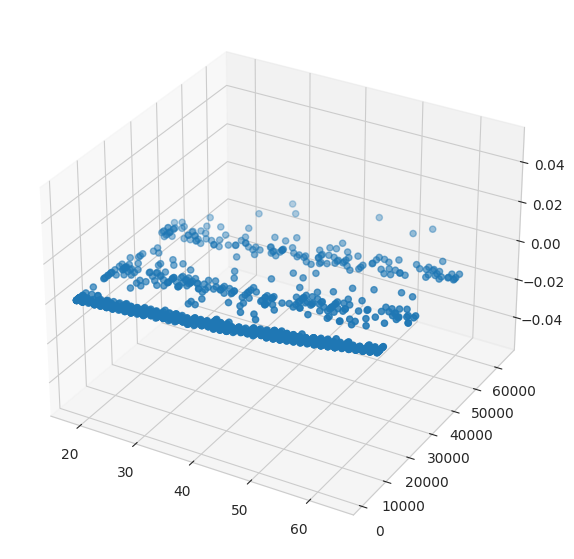

In [ ]:
# Visualising the Results
from mpl_toolkits.mplot3d import Axes3D

# Create figure
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

##-----------------------------

# Scatter actual data points
ax.scatter(df_Med['age'], y)


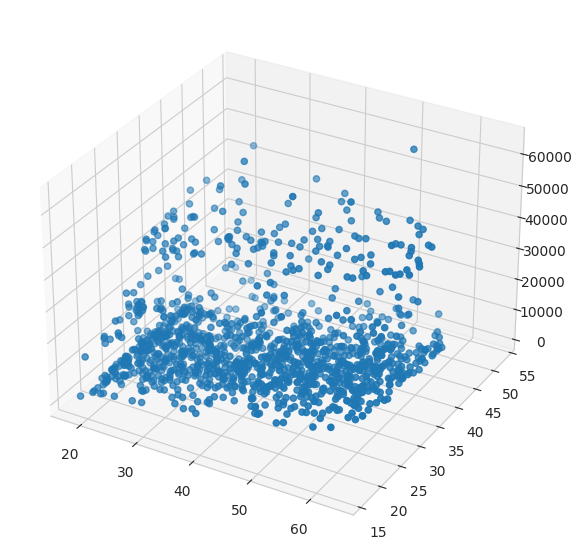

In [ ]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_Med['age'], df_Med['bmi'],y)

ValueError: X has 2 features, but LinearRegression is expecting 1 features as input.

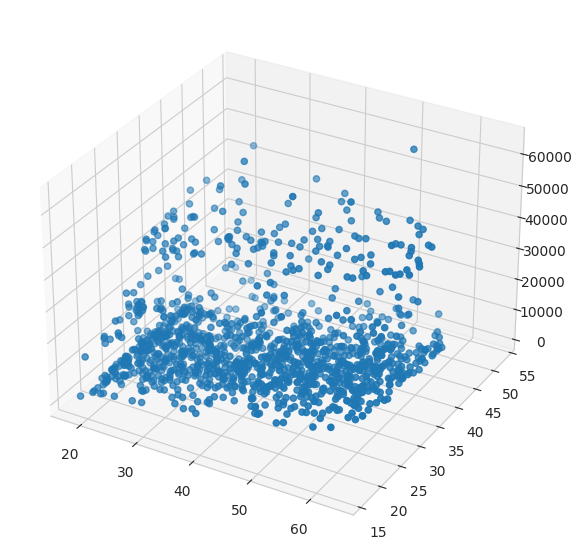

In [ ]:
# Visualising the Results
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_Med['age'], df_Med['bmi'], y)
# Create grid for plane
age_range = np.linspace(df_Med['age'].min(), df_Med['age'].max(), 20)
bmi_range = np.linspace(df_Med['bmi'].min(), df_Med['bmi'].max(), 20)

age_grid, bmi_grid = np.meshgrid(age_range, bmi_range)

# Predict sales for each grid point
charges_pred = linear_model.predict(
    np.c_[age_grid.ravel(), bmi_grid.ravel()]
)

charges_pred = charges_pred.reshape(age_grid.shape)



In [ ]:
# create grid for plane
sex_range = np.linspace(df_Med['sex'].min(), df_Med['sex'].max(), 20)
smoker_range = np.linspace(df_Med['smoker'].min(), df_Med['smoker'].max(), 20)
sex_grid, smoker_grid = np.meshgrid(sex_range, smoker_range)

In [ ]:
# Predict sales for each grid point
sales_pred = linear_model.predict(
    np.c_[sex_grid.ravel(), smoker_grid.ravel()])

ValueError: X has 2 features, but LinearRegression is expecting 3 features as input.

In [ ]:
# Plot regression plane
ax.plot_surface(sex_grid, smoker_grid, charges_pred, alpha=0.3)

NameError: name 'charges_pred' is not defined

In [ ]:

##-----------------------------

# Create grid for plane
sex_range = np.linspace(df_Med['sex'].min(), df_Med['sex'].max(), 20)
smoker_range = np.linspace(df_Med['smoker'].min(), df_Med['smoker'].max(), 20)

sex_grid, smoker_grid = np.meshgrid(sex_range, smoker_range)

# Predict sales for each grid point
sales_pred = linear_model.predict(
    np.c_[sex_grid.ravel(), smoker_grid.ravel()])

sales_pred = sales_pred.reshape(sex_grid.shape)

# Plot regression plane
ax.plot_surface(sex_grid, smoker_grid, charges_pred, alpha=0.3)

# Labels
ax.set_xlabel("sex charges")
ax.set_ylabel("smoker charges")
ax.set_zlabel("charges")

plt.title("Multiple Linear Regression Plane")
plt.show()